
========== DATA LOADING ==========

Columns in Dataset:
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

First 5 Rows:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               

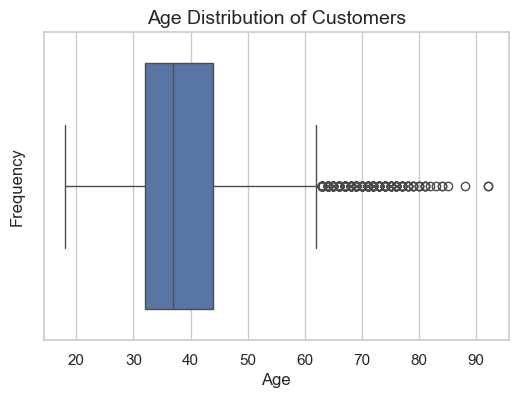


Explanation: The boxplot shows distribution of customer age, presence of outliers, and spread of data.



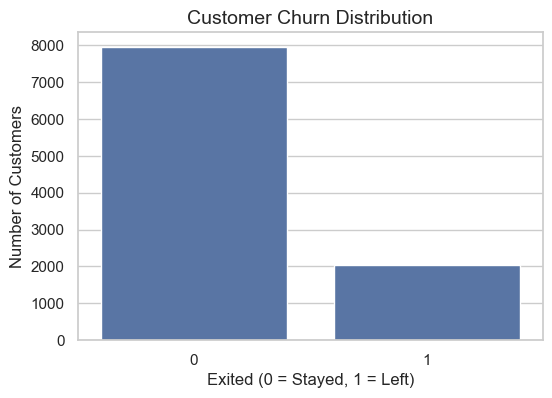

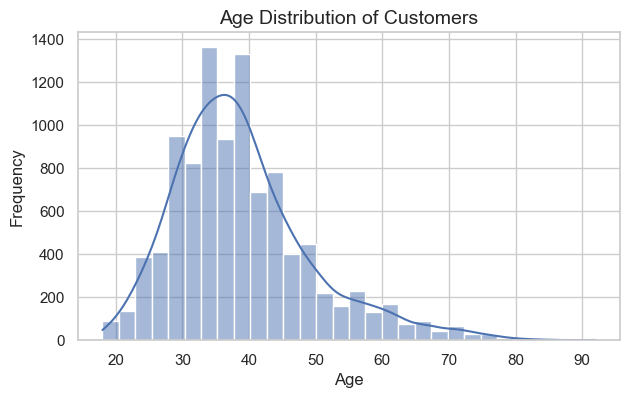

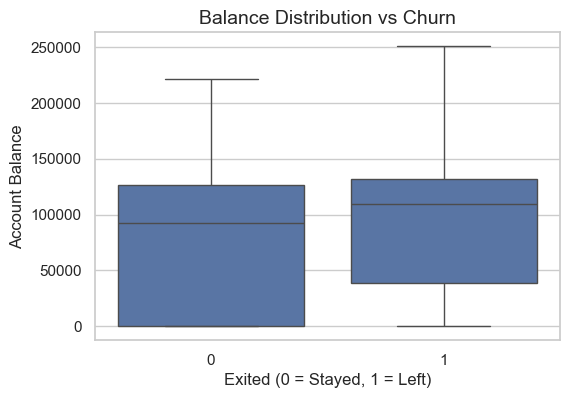

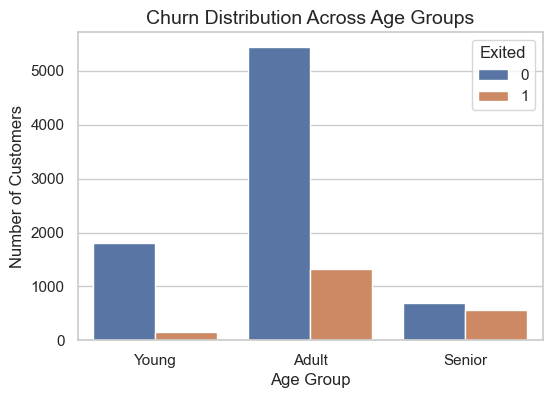

Overall EDA Insights

- Majority customers are middle-aged (30–40)
- Dataset is imbalanced (more non-churn customers)
- Balance and age influence churn behavior
- Certain age groups show higher churn risk


========== PIVOT TABLE ANALYSIS ==========

Average Balance by Age Group and Churn:
 Exited               0              1
AgeGroup                             
Young     70835.356083  101436.959247
Adult     73429.948975   90617.618997
Senior    71918.845960   89910.010284

Explanation: This table shows how average balance differs across age groups for customers who stayed vs churned.


========== MODEL BUILDING ==========

Training Data Shape: (8000, 8)
Testing Data Shape: (2000, 8)

Sample Predictions (Continuous): [0.2199528  0.14105086 0.28876889 0.40216341 0.04022199]
Sample Predictions (Binary): [0 0 0 0 0]

========== MODEL EVALUATION ==========

Model Accuracy: 0.8035

Explanation: Accuracy shows how many predictions were correctly classified.


========== INSIGHTS ========

In [2]:
#=========================================
# STEP 1- IMPORTING LIBRARIES
# ========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


# =========================================
# STEP 2 — DATA COLLECTION & LOADING
# =========================================
print("\n========== DATA LOADING ==========\n")

df = pd.read_csv("Churn_Modelling.csv")

print("Columns in Dataset:\n", df.columns)
print("\nFirst 5 Rows:\n", df.head())


# =========================================
# STEP 3 — DATA CLEANING
# =========================================
print("\n========== DATA CLEANING ==========\n")

print("Missing Values:\n", df.isnull().sum())

# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print("\nColumns after dropping unnecessary features:\n", df.columns)


# =========================================
# STEP 4 — DATA TRANSFORMATION
# =========================================
print("\n========== DATA TRANSFORMATION ==========\n")

# Convert categorical to numerical
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print("Data after Encoding:\n", df.head())


# =========================================
# STEP 5 — DATA DISCRETIZATION
# =========================================
print("\n========== DATA DISCRETIZATION ==========\n")

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 50, 100],
    labels=['Young', 'Adult', 'Senior']
)

print("Data with Age Groups:\n", df[['Age', 'AgeGroup']].head())


# =========================================
# STEP 6 — EXPLORATORY DATA ANALYSIS (EDA)
# =========================================
print("\n========== EXPLORATORY DATA ANALYSIS ==========\n")

print("Statistical Summary:\n", df.describe())

print("\n--- Age Statistics ---")
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())
print("Standard Deviation:", df['Age'].std())
print("Range:", df['Age'].max() - df['Age'].min())
print("IQR:", df['Age'].quantile(0.75) - df['Age'].quantile(0.25))
print("Skewness:", df['Age'].skew())
print("Kurtosis:", df['Age'].kurt())


# =========================================
# VISUALIZATION 1 — AGE DISTRIBUTION (BOXPLOT)
# =========================================
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])

plt.title("Age Distribution of Customers", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

print("\nExplanation: The boxplot shows distribution of customer age, presence of outliers, and spread of data.\n")

# =========================================
# VISUALIZATION 2 — Customer Churn Distribution
# =========================================
plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Exited (0 = Stayed, 1 = Left)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

# =========================================
# VISUALIZATION 3 — AGE DISTRIBUTION (Histogram)
# =========================================
plt.figure(figsize=(7,4))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution of Customers", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

# =========================================
# VISUALIZATION 4 — Balance vs Churn (Key Business Insight)
# =========================================
plt.figure(figsize=(6,4))

sns.boxplot(x='Exited', y='Balance', data=df)

plt.title("Balance Distribution vs Churn", fontsize=14)
plt.xlabel("Exited (0 = Stayed, 1 = Left)", fontsize=12)
plt.ylabel("Account Balance", fontsize=12)

plt.show()

# =========================================
# VISUALIZATION 5 — Age Group vs Churn
# =========================================
plt.figure(figsize=(6,4))

sns.countplot(x='AgeGroup', hue='Exited', data=df)

plt.title("Churn Distribution Across Age Groups", fontsize=14)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.legend(title="Exited")

plt.show()
## 📊 Overall EDA Insights
print("Overall EDA Insights")
print("""
- Majority customers are middle-aged (30–40)
- Dataset is imbalanced (more non-churn customers)
- Balance and age influence churn behavior
- Certain age groups show higher churn risk
""")

# =========================================
# PIVOT TABLE ANALYSIS
# =========================================
print("\n========== PIVOT TABLE ANALYSIS ==========\n")

pivoted_df = pd.pivot_table(
    df,
    values='Balance',
    index='AgeGroup',
    columns='Exited',
    aggfunc='mean'
)

print("Average Balance by Age Group and Churn:\n", pivoted_df)

print("\nExplanation: This table shows how average balance differs across age groups for customers who stayed vs churned.\n")


# =========================================
# STEP 7 — MODEL BUILDING
# =========================================
print("\n========== MODEL BUILDING ==========\n")

# Select numeric columns only
df_model = df.select_dtypes(include=['int64', 'float64'])

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# =========================================
# LINEAR REGRESSION MODEL
# =========================================
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

print("\nSample Predictions (Continuous):", y_pred[:5])
print("Sample Predictions (Binary):", y_pred_class[:5])


# =========================================
# STEP 8 — MODEL EVALUATION
# =========================================
print("\n========== MODEL EVALUATION ==========\n")

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_class)
print("Model Accuracy:", accuracy)

print("\nExplanation: Accuracy shows how many predictions were correctly classified.\n")


# =========================================
# STEP 9 — INSIGHTS & RECOMMENDATIONS
# =========================================
print("\n========== INSIGHTS ==========\n")

print("""
- The majority of customers fall in the 30–40 age range, indicating a strong middle-aged customer base.
- Age distribution shows a slight right skew due to the presence of older customers (outliers above 60).
- Churn behavior varies across age groups, suggesting age is an important factor in customer retention.
- Customers with lower engagement (e.g., inactivity) are more likely to churn.
- Account balance shows variation between churned and retained customers, indicating financial behavior influences retention.
""")

print("\n========== RECOMMENDATIONS ==========\n")

print("""
- Identify and target high-risk customers based on age and activity patterns.
- Improve engagement strategies such as personalized offers and communication.
- Provide tailored banking services for different age groups.
- Monitor high-balance customers closely to reduce potential revenue loss.
""")



# =========================================
# STEP 10 — CONCLUSION
# =========================================
print("\n========== CONCLUSION ==========\n")

print("""
This project successfully demonstrates:
- Data preprocessing
- Statistical analysis
- Regression modeling

Linear Regression helped identify churn patterns and support decision-making.
""")


# =========================================
# STEP 11 — FUTURE WORK
# =========================================
print("\n========== FUTURE WORK ==========\n")

print("""
- Use advanced models like Logistic Regression, Random Forest
- Perform better feature engineering
- Work with real-time datasets
- Deploy using Streamlit or Flask
""")
